## Bandwidth performance of Multi-core Segmented Operations

> The goal is to understand the "peak performance" of the Multi-core Segmented Operations

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

densities = [0.001, 0.01]

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75

_MARKERS = ["o", "^", "v", "<", ">", "s", "d"]

_SNS_PARAMS = {"markers":_MARKERS, "dashes":True, "markersize": 10}

In [37]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [2]:
S = 128

df = pd.DataFrame()

copy_dataframe = pd.read_csv(f"./bench_results_copy_fp32.csv")
copy_dataframe["operator"] = "MEMCOPY (fp32)"
copy_dataframe["gelemps"] = (copy_dataframe["size"] / 1e9) / (copy_dataframe["time_us"] / 1e6)
copy_dataframe['mem_bytes'] = (copy_dataframe['size'] * 4)  + copy_dataframe['outputsize'] * 4
copy_dataframe['bandwidth_gbps'] = (copy_dataframe['mem_bytes']) / (copy_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, copy_dataframe])

mcscan_dataframe = pd.read_csv(f"./bench_results_mcscan_{S}_fp16.csv")
mcscan_dataframe["operator"] = "SCAN (fp16)"
mcscan_dataframe["gelemps"] = (mcscan_dataframe["size"] / 1e9) / (mcscan_dataframe["time_us"] / 1e6)
mcscan_dataframe['mem_bytes'] = (mcscan_dataframe['size'] * 2)  + mcscan_dataframe['size'] * 4
mcscan_dataframe['bandwidth_gbps'] = (mcscan_dataframe['mem_bytes']) / (mcscan_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, mcscan_dataframe])


mcscan_dataframe = pd.read_csv(f"./bench_results_mcscan_{S}_int8.csv")
mcscan_dataframe["operator"] = "SCAN (int8)"
mcscan_dataframe["gelemps"] = (mcscan_dataframe["size"] / 1e9) / (mcscan_dataframe["time_us"] / 1e6)
mcscan_dataframe['mem_bytes'] = (mcscan_dataframe['size'] * 1)  + mcscan_dataframe['size'] * 4
mcscan_dataframe['bandwidth_gbps'] = (mcscan_dataframe['mem_bytes']) / (mcscan_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, mcscan_dataframe])

diff_dataframe = pd.read_csv(f"./bench_results_diff_cann_fp32.csv")
diff_dataframe["operator"] = "DIFF (fp32)"
diff_dataframe["gelemps"] = (diff_dataframe["size"] / 1e9) / (diff_dataframe["time_us"] / 1e6)
diff_dataframe['mem_bytes'] = (diff_dataframe['size'] * 4)  + diff_dataframe['outputsize'] * 4
diff_dataframe['bandwidth_gbps'] = (diff_dataframe['mem_bytes']) / (diff_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, diff_dataframe])

# Input -> FP32 + INT8 -> 4 + 1 | Output -> FP32 -> 4
compress_dataframe = pd.read_csv(f"./bench_results_compress_{S}_{densities[0]}_fp32.csv")
compress_dataframe["operator"] = f"COMPRESS ({densities[0]})"
compress_dataframe["gelemps"] = (compress_dataframe["size"] / 1e9) / (compress_dataframe["time_us"] / 1e6)
compress_dataframe['mem_bytes'] = (compress_dataframe['size'] * (4+1))  + compress_dataframe['outputsize'] * 4
compress_dataframe['bandwidth_gbps'] = (compress_dataframe['mem_bytes']) / (compress_dataframe['time_us'] * 1000) #GB/s
df = pd.concat([df, compress_dataframe])

for density in densities:

    # Input -> FP32 + INT32 + FP32 (small)  | Output -> FP32 
    revert_dataframe = pd.read_csv(f"./bench_results_seg_scan_mc_revert_{density}_fp32.csv")
    revert_dataframe["operator"] = f"REVERT ({density})"
    revert_dataframe["gelemps"] = (revert_dataframe["size"] / 1e9) / (revert_dataframe["time_us"] / 1e6)
    revert_dataframe['mem_bytes'] = (revert_dataframe['size'] * 3 * 4)  + revert_dataframe['outputsize'] * 4
    revert_dataframe['bandwidth_gbps'] = (revert_dataframe['mem_bytes']) / (revert_dataframe['time_us'] * 1000) #GB/s
    df = pd.concat([df, revert_dataframe])


## Paper plots

<Figure size 1100x550 with 0 Axes>

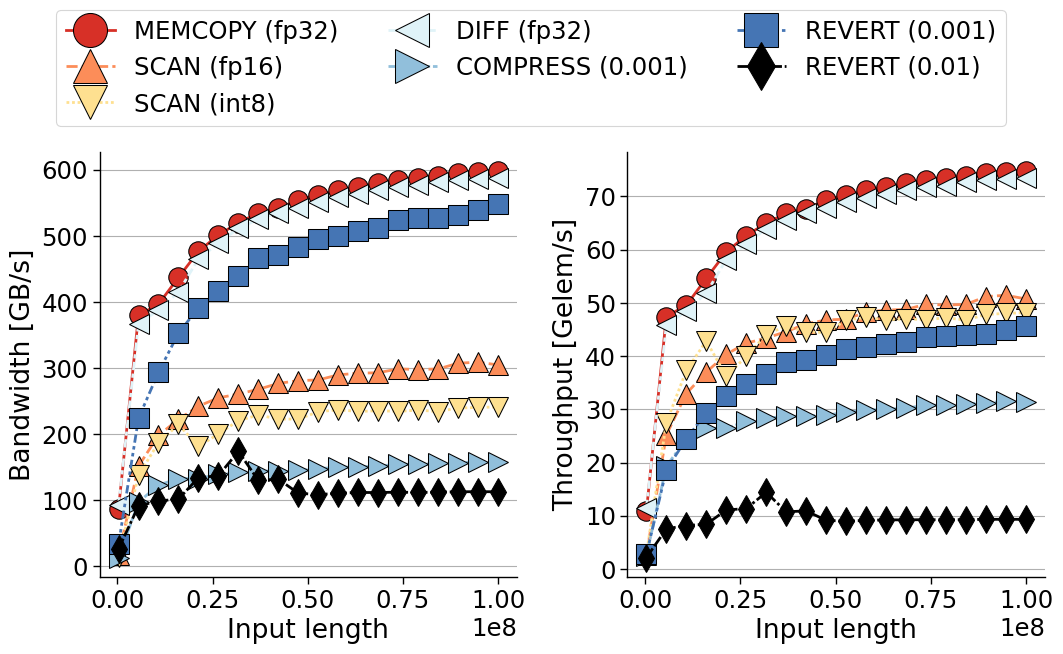

<Figure size 870x627 with 0 Axes>

In [6]:
plt.figure(figsize=(11, 5.5))
### Colorbrewer colors
#d73027
#fc8d59
#fee090
#e0f3f8
#91bfdb
#4575b4

color_palette = [### Colorbrewer colors
"#d73027",
"#fc8d59",
"#fee090",
"#e0f3f8",
"#91bfdb",
"#4575b4",
"black"]

fig, axes = plt.subplots(1,2, figsize=(11,5.5), sharex=True, sharey=False)
axes[0].grid(axis='y')
axes[1].grid(axis='y')
_SNS_PARAMS = {"hue":'operator', "style":'operator', "markers":_MARKERS, "markersize": 14, "dashes":True}

ax = sns.lineplot(data=df, x='size', y='gelemps', ax=axes[1], palette=color_palette,markeredgecolor='black', **_SNS_PARAMS)

# ax.set_title(f"Throughput of Parallel Primitives (SCD,SCCR)")
ax.set_xlabel("Input length")
ax.set_ylabel("Throughput [Gelem/s]")
sns.despine(right = True)
plt.tight_layout()

ax = sns.lineplot(data=df, x='size', y='bandwidth_gbps', ax=axes[0], palette=color_palette,markeredgecolor='black', **_SNS_PARAMS)

# ax.set_title(f"Bandwidth of Parallel Primitives (SCD,SSCR)")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.tight_layout()

for ax in axes:
    ax.legend_.remove()

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(by_label.values(), by_label.keys(), loc="center", markerscale=_LEGEND_MARKER_SCALE, bbox_to_anchor=(0.5,1.1), ncol=3)

fig.savefig(f"bw_gelemps_mc_seg_ops_single_column.pdf", bbox_inches='tight')
fig.savefig(f"bw_gelemps_mc_seg_ops_single_column.png")
plt.show()
plt.clf()
